In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

In [8]:
data_dir = Path(".")

Reading file: req_200_batch_8_layer_25_conf_0.8_rebatching_copy_num_ee_threshold_4_run_01.csv
Reading file: req_200_batch_8_layer_25_conf_0.8_rebatching_copy_num_ee_threshold_0_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_0.9_median_copy_num_ee_threshold_-1_run_01.csv
Reading file: req_200_batch_8_layer_25_conf_0.8_rebatching_copy_num_ee_threshold_2_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_0.9_rebatching_copy_num_ee_threshold_0_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_0.9_rebatching_copy_num_ee_threshold_5_run_02.csv
Reading file: req_200_batch_8_layer_25_conf_0.8_rebatching_copy_num_ee_threshold_3_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_0.9_latency-only_copy_num_ee_threshold_-1_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_1.0_off_copy_num_ee_threshold_-1_run_01.csv
Reading file: req_200_batch_8_layer_25_conf_0.8_lazy_copy_num_ee_threshold_-1_run_01.csv
Reading file: req_200_batch_8_layer_30_conf_0.9_rebatching_copy_num_ee_

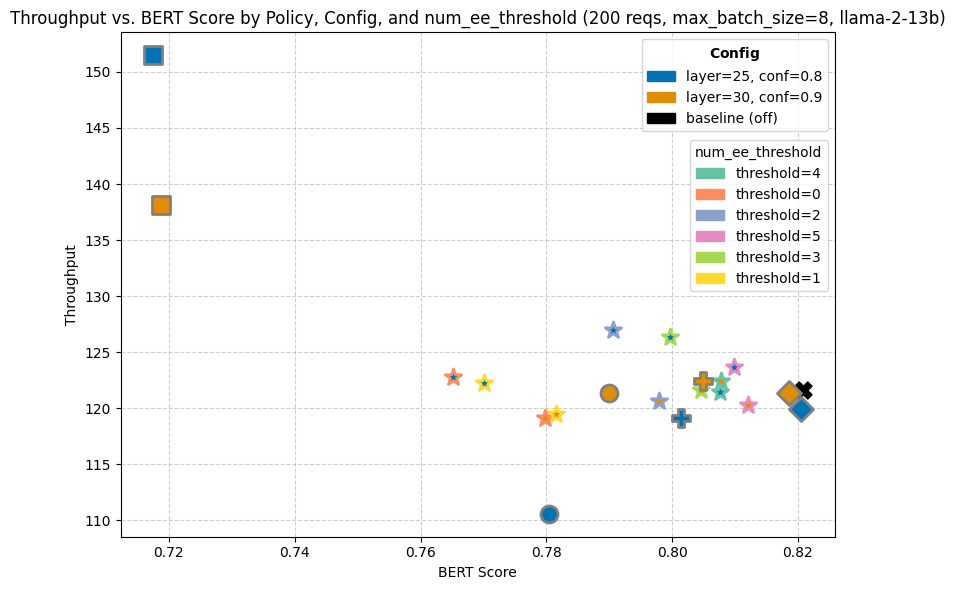

In [40]:
def plot_throughput_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score,
    creating legends for policies (markers), configurations (colors),
    and differentiates different num_ee_thresholds that are not -1 by marker edge color.
    Uses 'off' policy as baseline instead of 'latency-only'.
    Loads cleaned '_numeric.csv' files.
    """
    import re
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    import numpy as np

    # Define policies with markers
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "latency-only": {"label": "latency-only", "marker": "o"},
        "off": {"label": "off", "marker": "X"},
    }

    # Define color palette for configurations
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("25", "0.8"): palette[0],
        ("30", "0.9"): palette[1],
    }

    # Color palette for threshold highlighting
    threshold_colors = sns.color_palette("Set2", n_colors=8) # up to 8 different thresholds

    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    rows = []
    baseline_rows = []

    # Iterate through the *_numeric.csv files
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name

        # Match relevant policy files with regex; capture threshold (can be any value)
        m = re.search(
            r"req_200_batch_[0-9]+_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_num_ee_threshold_([^_]+)_run_[0-9]+\.csv$",
            fname
        )
        if m:
            layer, conf, policy, threshold = m.group(1), m.group(2), m.group(3), m.group(4)
            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map and policy != 'latency-only':
                continue

            print(f"Reading file: {csv_path}")
            df = pd.read_csv(csv_path)
            mean_bert = df["bert_score"].mean()
            mean_throughput = df["throughput"].mean()

            row = {
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": mean_throughput,
                "bert_score": mean_bert,
                "num_ee_threshold": threshold,
            }

            if policy == "off":
                baseline_rows.append(row)
            else:
                rows.append(row)

    plot_df = pd.DataFrame(rows)
    baseline_df = pd.DataFrame(baseline_rows)

    print(plot_df)
    print(f"Found {len(plot_df)} data points to plot.")
    print(f"Found {len(baseline_df)} baseline (off) data points.")

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot baseline 'off' points in black with 'X' marker
    if not baseline_df.empty:
        ax.scatter(
            baseline_df["bert_score"], baseline_df["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3, label="baseline (off)"
        )

    # Map unique non--1 thresholds to colors
    unique_thresholds = [t for t in plot_df["num_ee_threshold"].unique() if t != "-1" and t is not None]
    threshold_color_map = {t: threshold_colors[i % len(threshold_colors)] for i, t in enumerate(unique_thresholds)}

    # Plot other policies with their markers, config colors, and threshold edge color
    for policy, p_info in policies.items():
        if policy == "off":
            continue  # already plotted baseline
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            for t, subsubdf in subdf.groupby("num_ee_threshold"):
                # Threshold highlighting only for thresholds not equal to -1
                edge_col = threshold_color_map.get(t, "grey") if t != "-1" else "grey"
                if not subsubdf.empty:
                    ax.scatter(
                        subsubdf["bert_score"], subsubdf["throughput"],
                        marker=p_info["marker"], color=color, s=150, zorder=3,
                        edgecolors=edge_col, linewidths=2,
                        label=f"{policy} (threshold={t})" if t != "-1" else policy
                    )

    # Create legend handles for configurations
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=25, conf=0.8"),
        mpatches.Patch(color=palette[1], label="layer=30, conf=0.9"),
        mpatches.Patch(color='black', label="baseline (off)"),
    ]
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper right', bbox_to_anchor=(1, 1))
    ax.add_artist(config_legend)

    # Create legend handles for policies
    policy_order = ["rebatching", "eager", "lazy", "median", "latency-only", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='upper right', bbox_to_anchor=(1, 0.78))

    # Legend for thresholds (excluding -1)
    threshold_handles = [
        mpatches.Patch(color=c, label=f"threshold={t}")
        for t, c in threshold_color_map.items()
    ]
    if threshold_handles:
        ax.legend(handles=threshold_handles, title="num_ee_threshold", loc='upper right', bbox_to_anchor=(1, 0.8))

    ax.set_xlabel("BERT Score")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. BERT Score by Policy, Config, and num_ee_threshold (200 reqs, max_batch_size=8, llama-2-13b)")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# Example usage; replace `data_dir` with your actual directory path
plot_throughput_vs_bert_from_csvs(data_dir)

Reading file: req_500_batch_4_layer_30_conf_0.9_rebatching_copy.csv
Reading file: req_500_batch_4_layer_30_conf_0.9_eager_copy.csv
Reading file: req_500_batch_4_layer_25_conf_0.8_median_copy.csv
Reading file: req_500_batch_4_layer_30_conf_1.0_off_copy.csv
Reading file: req_500_batch_4_layer_30_conf_0.9_lazy_copy.csv
Reading file: req_500_batch_4_layer_30_conf_0.9_median_copy.csv
Reading file: req_500_batch_4_layer_30_conf_0.9_latency-only_copy.csv
Reading file: req_500_batch_4_layer_25_conf_0.8_eager_copy.csv
Reading file: req_500_batch_4_layer_25_conf_0.8_rebatching_copy.csv
Reading file: req_500_batch_4_layer_25_conf_0.8_lazy_copy.csv
Reading file: req_500_batch_4_layer_25_conf_0.8_latency-only_copy.csv
         policy layer conf  throughput  p95_conf_score_ee
0    rebatching    30  0.9   73.594423           0.914551
1         eager    30  0.9   87.920194           0.119263
2        median    25  0.8   73.031209           0.033817
3          lazy    30  0.9   73.192856           0.91

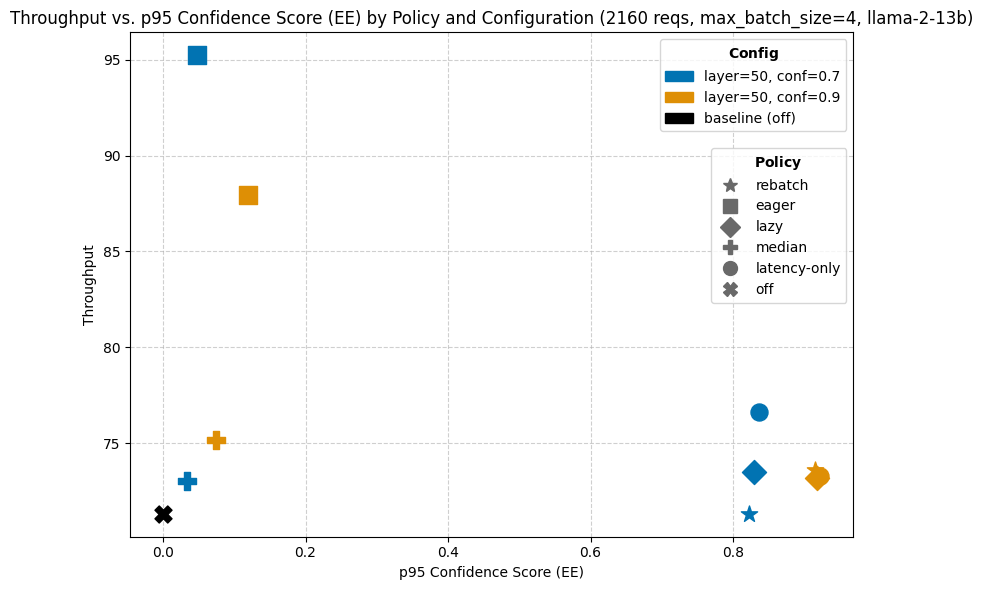

In [ ]:
def plot_throughput_vs_p95_conf_from_csvs(data_dir):
    """
    Plots throughput vs. p95_conf_score_ee, creating legends for policies (markers)
    and configurations (colors). Uses 'off' policy as baseline instead of 'latency-only'.
    Loads cleaned '*_numeric.csv' files.
    """
    import re
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines

    # Define policies with markers
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "latency-only": {"label": "latency-only", "marker": "o"},
        "off": {"label": "off", "marker": "X"},
    }

    # Define color palette for configurations
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("25", "0.8"): palette[0],
        ("30", "0.9"): palette[1],
    }

    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)
    rows = []
    baseline_rows = []
    # Iterate through *_numeric.csv files
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # Match relevant policy files with regex
        m = re.search(
            r"req_500_batch_[0-9]+_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy+\.csv$",
            fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)
            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue
            print(f"Reading file: {csv_path}")
            df = pd.read_csv(csv_path)
            mean_conf = df["p95_conf_score_ee"].mean()
            mean_throughput = df["throughput"].mean()
            row = {
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": mean_throughput,
                "p95_conf_score_ee": mean_conf,
            }
            if policy == "off":
                baseline_rows.append(row)
            else:
                rows.append(row)
    plot_df = pd.DataFrame(rows)
    baseline_df = pd.DataFrame(baseline_rows)
    print(plot_df)
    print(f"Found {len(plot_df)} data points to plot.")
    print(f"Found {len(baseline_df)} baseline (off) data points.")
    fig, ax = plt.subplots(figsize=(8, 6))
    # Plot baseline 'off' points in black with 'X' marker
    if not baseline_df.empty:
        ax.scatter(
            baseline_df["p95_conf_score_ee"], baseline_df["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3, label="baseline (off)"
        )
    # Plot other policies with their markers and colors per config
    for policy, p_info in policies.items():
        if policy == "off":
            continue  # already plotted baseline
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                ax.scatter(
                    subdf["p95_conf_score_ee"], subdf["throughput"],
                    marker=p_info["marker"], color=color, s=150, zorder=3
                )
    # Create legend handles for configurations
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=50, conf=0.7"),
        mpatches.Patch(color=palette[1], label="layer=50, conf=0.9"),
        mpatches.Patch(color='black', label="baseline (off)"),
    ]
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                             loc='upper right', bbox_to_anchor=(1, 1))
    ax.add_artist(config_legend)
    # Create legend handles for policies
    policy_order = ["rebatching", "eager", "lazy", "median", "latency-only", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='lower right', bbox_to_anchor=(1, 0.45))
    ax.set_xlabel("p95 Confidence Score (EE)")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. p95 Confidence Score (EE) by Policy and Configuration (500 reqs, max_batch_size=4, llama-2-13b)")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_throughput_vs_p95_conf_from_csvs(data_dir)

Matching file: req_2160_batch_8_layer_30_conf_0.9_rebatching_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_lazy_copy_run_01_numeric.csv


Matching file: req_2160_batch_8_layer_30_conf_0.9_lazy_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_median_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_rebatching_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_eager_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_0.9_eager_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_0.9_median_copy_run_01_numeric.csv
Found 8 data points:
       policy layer conf      tpot  bert_score
0  rebatching    30  0.9  0.007589    0.804730
1        lazy    25  0.8  0.007654    0.831891
2        lazy    30  0.9  0.007727    0.829687
3      median    25  0.8  0.007607    0.821679
4  rebatching    25  0.8  0.007493    0.789330
5       eager    25  0.8  0.006544    0.727297
6       eager    30  0.9  0.006565    0.736999
7      median    30  0.9  0.007590    0.825833


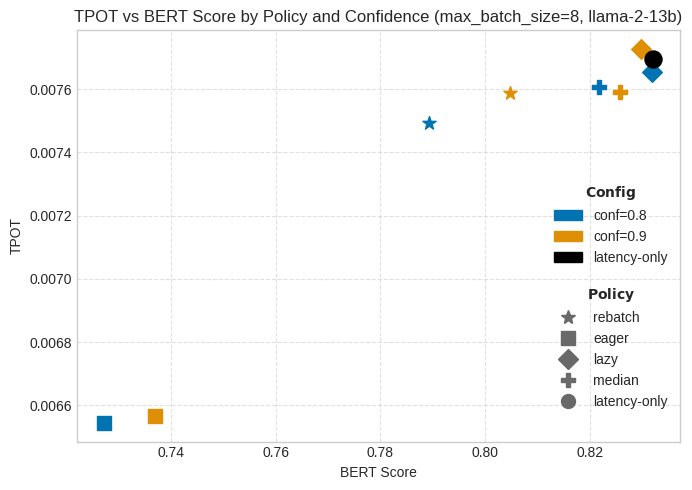

In [11]:
def plot_tpot_vs_bert_from_csvs(data_dir):
    """
    Plots TPOT vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure. Uses 'latency-only' as the baseline.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "latency-only": {"label": "latency-only", "marker": "o", "color": "black"},  # baseline
    }
    confs = ["0.8", "0.9"]
    layers = ["25", "30"]

    # Prepare data
    rows = []
    baseline = None

    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        
        # Identify baseline CSV (adjust name if needed)
        if fname == "req_2160_batch_8_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv":
            df = pd.read_csv(csv_path, engine='python')
            baseline = {
                "bert_score": df["bert_score"].mean(),
                "tpot": df["tpot"].mean(),
            }
            continue  # skip adding to normal data

        # Match other files with expected pattern
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_run_01_numeric\.csv$", fname)
        print(f"Matching file: {fname}")
        if m:
            layer = m.group(1)
            conf = m.group(2)
            policy = m.group(3)
            
            if policy not in policies:
                continue
            if layer not in layers:
                continue
            if conf not in confs:
                continue

            df = pd.read_csv(csv_path, engine='python')
            tpot = df["tpot"].mean()
            bert_score = df["bert_score"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "tpot": tpot,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points:")
    print(plot_df)

    # Set up color palette for confs
    palette = sns.color_palette("colorblind", n_colors=2)
    conf_color_map = {c: palette[i] for i, c in enumerate(confs)}

    fig, ax = plt.subplots(figsize=(7, 5))

    # Plot the latency-only baseline
    if baseline:
        ax.scatter(
            baseline["bert_score"], baseline["tpot"],
            marker=policies["latency-only"]["marker"], color=policies["latency-only"]["color"], s=150, zorder=3,
            label="latency-only"
        )

    # Plot data points for other policies and configs
    for policy, info in policies.items():
        if policy == "latency-only":
            continue
        for conf in confs:
            subdf = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
            if not subdf.empty:
                ax.scatter(
                    subdf["bert_score"], subdf["tpot"],
                    marker=info["marker"], color=conf_color_map[conf], s=100,
                    label=f"{info['label']} (conf={conf})"
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="conf=0.8"),
        mpatches.Patch(color=palette[1], label="conf=0.9"),
        mpatches.Patch(color=policies["latency-only"]["color"], label="latency-only")
    ]
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='lower right', bbox_to_anchor=(1, 0.4))
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "eager", "lazy", "median", "latency-only"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='lower right', bbox_to_anchor=(1, 0.05))

    # Remove duplicate labels in legend if any (optional, improves clarity)

    ax.set_xlabel("BERT Score")
    ax.set_ylabel("TPOT")
    ax.set_title("TPOT vs BERT Score by Policy and Confidence (max_batch_size=8, llama-2-13b)")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_tpot_vs_bert_from_csvs(data_dir)

Found 'latency-only' policy baseline throughput: 116.73
Matching file: req_2160_batch_8_layer_30_conf_0.9_rebatching_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_lazy_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_0.9_lazy_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_median_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_rebatching_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_25_conf_0.8_eager_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_0.9_eager_copy_run_01_numeric.csv
Matching file: req_2160_batch_8_layer_30_conf_0.9_median_copy_run_01_numeric.csv
Found 8 data points for main policies:
       policy conf  ee_proportion  throughput
0  rebatching  0.9       9.412397  121.429093
1        lazy  0.8       0.045344  116.946367
2        lazy  0.9       0.026

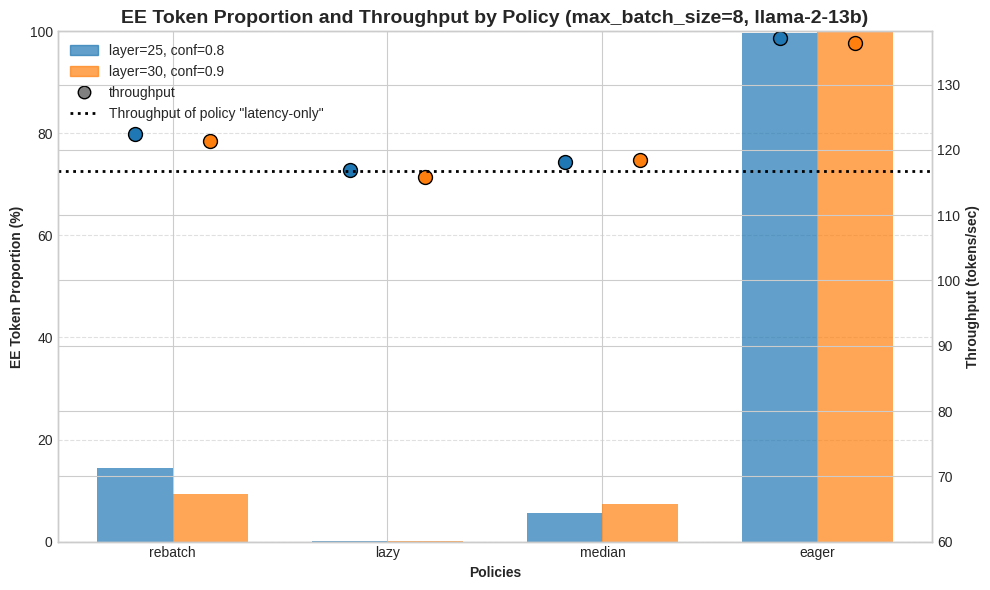

In [12]:
def plot_ee_proportion_and_throughput(data_dir):
    """
    Plots EE token proportion and throughput, including a baseline "latency-only" policy.

    This function creates a bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Left Y-axis: EE Token Proportion (%)
    - Right Y-axis: Throughput (overlaid as dots)
    - A horizontal dotted line shows the throughput of the "latency-only" policy baseline.
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    # 1. Read baseline "latency-only" policy data from the specific CSV file
    baseline_throughput = None
    baseline_file = data_dir / "req_2160_batch_8_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv"
    if baseline_file.exists():
        df_baseline = pd.read_csv(baseline_file, engine='python')
        if "throughput" in df_baseline.columns:
            baseline_throughput = df_baseline["throughput"].mean()
            print(f"Found 'latency-only' policy baseline throughput: {baseline_throughput:.2f}")
    else:
        print(f"Note: '{baseline_file.name}' not found. Skipping baseline throughput line.")

    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }
    confs = ["0.8", "0.9"]

    # Prepare data for main policies
    rows = []
    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        print(f"Matching file: {fname}")
        # Match relevant policy/conf files (excluding latency-only baseline)
        m = re.search(r"conf_([0-9.]+)_([a-z\-]+)_copy_run_01\_numeric.csv$", fname)
        if m:
            conf, policy = m.group(1), m.group(2)
            if policy in policies and conf in confs:
                try:
                    df = pd.read_csv(csv_path, engine='python')
                except Exception as e:
                    print(f"Warning: Failed to read {fname} due to: {e}")
                    continue
                total_tokens = df["num_ee_tokens"].mean() + df["num_no_ee_tokens"].mean()
                ee_prop = (df["num_ee_tokens"].mean() / total_tokens) * 100 if total_tokens > 0 else 0
                throughput = df["throughput"].mean() if "throughput" in df.columns else np.nan
                rows.append({
                    "policy": policy,
                    "conf": conf,
                    "ee_proportion": ee_prop,
                    "throughput": throughput,
                })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points for main policies:\n{plot_df}")

    # Set up the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    policy_names = list(policies.values())
    x_positions = np.arange(len(policy_names))
    bar_width = 0.35
    colors = ['#1f77b4', '#ff7f0e']

    # --- Plot Bars and Scatter Dots ---
    for i, conf in enumerate(confs):
        x_offset = i * bar_width - bar_width / 2
        for j, policy in enumerate(policies.keys()):
            data = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
            if not data.empty:
                d = data.iloc[0]
                ax1.bar(j + x_offset, d["ee_proportion"], bar_width, color=colors[i], alpha=0.7)
                ax2.scatter(j + x_offset, d["throughput"], color=colors[i], s=100, marker='o',
                            edgecolors='black', linewidth=1)

    # 2. Plot the baseline "latency-only" throughput as a horizontal dotted line if available
    if baseline_throughput is not None:
        ax2.axhline(y=baseline_throughput, color='black', linestyle=':', linewidth=2)

    # --- Legend Creation ---
    legend_handles = [
        mpatches.Patch(color=colors[0], label='layer=25, conf=0.8', alpha=0.7),
        mpatches.Patch(color=colors[1], label='layer=30, conf=0.9', alpha=0.7),
        mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=9,
                      markeredgecolor='black', label='throughput')
    ]

    # Add handle for baseline throughput line if available
    if baseline_throughput is not None:
        baseline_handle = mlines.Line2D([], [], color='black', linestyle=':',
                                       linewidth=2, label='Throughput of policy "latency-only"')
        legend_handles.append(baseline_handle)

    ax1.legend(handles=legend_handles, loc='upper left')

    # --- Plot Customization ---
    ax1.set_xlabel('Policies', fontweight='bold')
    ax1.set_ylabel('EE Token Proportion (%)', fontweight='bold')
    ax2.set_ylabel('Throughput (tokens/sec)', fontweight='bold')
    ax1.set_title('EE Token Proportion and Throughput by Policy (max_batch_size=8, llama-2-13b)', fontweight='bold', fontsize=14)
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(policy_names)
    ax1.set_ylim(0, 100)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

    if not plot_df.empty and plot_df['throughput'].min() > 0:
        ax2.set_ylim(bottom=60)

    fig.tight_layout()
    plt.show()

plot_ee_proportion_and_throughput(data_dir)

Baseline 'latency-only' throughput: 116.73, BERT: 0.8320

Averaged throughput and BERT scores by policy, layer, conf:
       policy layer conf  throughput  bert_score
0       eager    25  0.8  137.102110    0.727297
1       eager    30  0.9  136.313034    0.736999
2        lazy    25  0.8  116.946367    0.831891
3        lazy    30  0.9  115.920878    0.829687
4      median    25  0.8  118.118095    0.821679
5      median    30  0.9  118.473895    0.825833
6  rebatching    25  0.8  122.449911    0.789330
7  rebatching    30  0.9  121.429093    0.804730

Debugging 'lazy' policy intermediate values:
Layer: 25, Conf: 0.8, Throughput: 116.9464, BERT: 0.8319, Numerator: 0.2186, Denominator: 0.007986
Layer: 30, Conf: 0.9, Throughput: 115.9209, BERT: 0.8297, Numerator: -0.8069, Denominator: 0.228400

  policy layer conf  throughput  bert_score  efficacy_numerator  \
2   lazy    25  0.8  116.946367    0.831891            0.218565   

   efficacy_denominator  
2              0.007986  

EE Effi

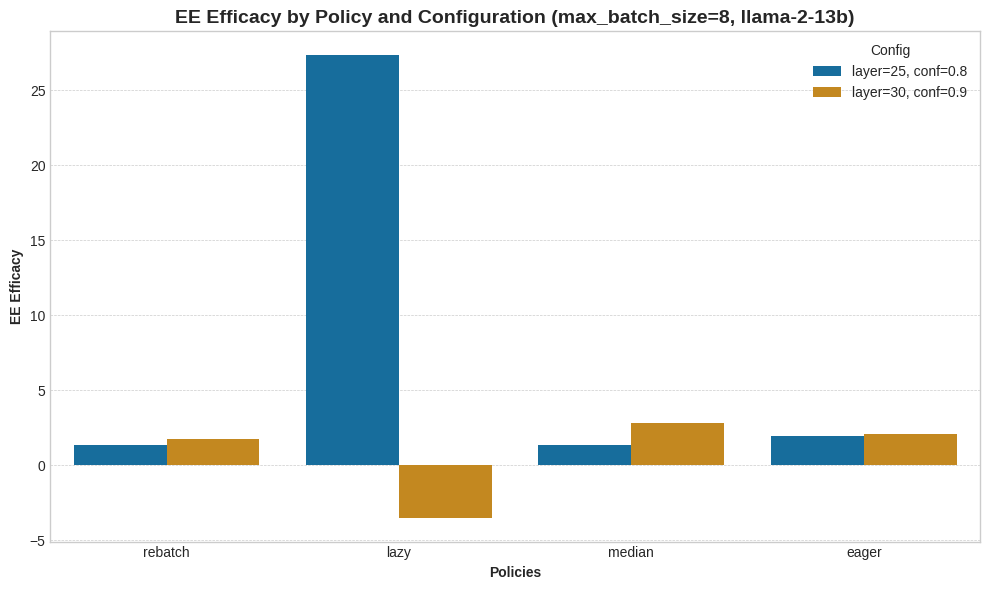

In [ ]:
def plot_ee_efficacy(data_dir: Path):
    import re
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }
    confs = ["0.8", "0.9"]
    layers = ["25", "30"]  # adjust as needed

    run_pattern = re.compile(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_run_([0-9]+)_numeric\.csv$")
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    baseline = None
    baseline_fname = "req_2160_batch_8_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv"

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        if fname == baseline_fname:
            df_baseline = pd.read_csv(csv_path)
            baseline = {
                "throughput": df_baseline["throughput"].mean(),
                "bert_score": df_baseline["bert_score"].mean()
            }
            continue
        else:
            m = run_pattern.search(fname)
            if not m:
                continue
            layer, conf, policy_key, run_id = m.groups()
            if policy_key not in policies:
                continue
            if conf not in confs or layer not in layers:
                continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "layer": layer,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "bert_score": df["bert_score"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    df = pd.DataFrame(rows)

    if baseline is None:
        print(f"Error: Baseline '{baseline_fname}' data not found.")
        return

    off_throughput = baseline["throughput"]
    off_bert_score = baseline["bert_score"]
    print(f"Baseline 'latency-only' throughput: {off_throughput:.2f}, BERT: {off_bert_score:.4f}")

    df_policy = df.groupby(['policy', 'layer', 'conf']).agg({
        "throughput": "mean",
        "bert_score": "mean"
    }).reset_index()

    # Debug: print all averages before efficacy calculation
    print("\nAveraged throughput and BERT scores by policy, layer, conf:")
    print(df_policy)

    # Calculate numerator and denominator explicitly for debugging
    df_policy["efficacy_numerator"] = df_policy["throughput"] - off_throughput
    df_policy["efficacy_denominator"] = (off_bert_score - df_policy["bert_score"]) * 100

    # Debug: specifically print 'lazy' policy intermediate values to diagnose
    lazy_debug = df_policy[df_policy["policy"] == "lazy"]
    print("\nDebugging 'lazy' policy intermediate values:")
    for _, row in lazy_debug.iterrows():
        print(
            f"Layer: {row['layer']}, Conf: {row['conf']}, Throughput: {row['throughput']:.4f}, "
            f"BERT: {row['bert_score']:.4f}, Numerator: {row['efficacy_numerator']:.4f}, "
            f"Denominator: {row['efficacy_denominator']:.6f}"
        )

    # Watch out for very small denominator values that may inflate efficacy
    small_denominator = lazy_debug[lazy_debug["efficacy_denominator"].abs() < 1e-2]
    if not small_denominator.empty:
        print("\nWarning: 'lazy' policy has very small denominator values which can cause inflated efficacy:")
        print(small_denominator)

    # Now calculate efficacy safely, avoiding division by zero
    df_policy["ee_efficacy"] = df_policy.apply(
        lambda r: r["efficacy_numerator"] / r["efficacy_denominator"] if abs(r["efficacy_denominator"]) > 1e-8 else float('inf'),
        axis=1
    )

    # Print final EE efficacies for every policy
    for policy in df_policy["policy"].unique():
        subdf = df_policy[df_policy["policy"] == policy]
        print(f"\nEE Efficacies for policy: {policy}")
        for _, row in subdf.iterrows():
            print(f"  Layer: {row['layer']}, Conf: {row['conf']}, Efficacy: {row['ee_efficacy']:.4f}")

    # Prepare display variables and plotting as before
    df_policy["policy_display"] = df_policy["policy"].map(policies)
    df_policy["config"] = df_policy.apply(lambda r: f'layer={r["layer"]}, conf={r["conf"]}', axis=1)
    config_labels = df_policy["config"].unique().tolist()
    palette = sns.color_palette("colorblind", n_colors=len(config_labels))

    import matplotlib.pyplot as plt
    import seaborn as sns   

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_policy,
        x='policy_display',
        y='ee_efficacy',
        hue='config',
        order=[policies[p] for p in policies],
        palette=palette
    )
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('EE Efficacy', fontweight='bold')
    ax.set_title('EE Efficacy by Policy and Configuration (max_batch_size=8, llama-2-13b)', fontweight='bold', fontsize=14)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')
    ax.legend(title="Config")
    plt.tight_layout()
    plt.show()

plot_ee_efficacy(data_dir)

In [41]:
def calculate_theoretical_improve(data_dir):
    """
    Load CSV files for each policy and calculate theoretical improvement relative to baseline:
    theoretical_improve = (num_ee_tokens / (num_ee_tokens + num_no_ee_tokens)) * 
                          ((total_layers - shallow_exit_layers) / total_layers)
    total_layers is fixed at 40.
    shallow_exit_layers is extracted from filename after 'layer_'.

    Actual improvement is computed relative to "off" policy throughput.
    """

    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    policies = ["rebatching", "eager", "lazy", "median", "latency-only", "off"]
    total_layers = 40
    rows = []

    baseline_throughput = None

    # Use 'off' as baseline policy throughput
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        if "off" in fname:   # changed from "latency-only"
            try:
                df_baseline = pd.read_csv(csv_path)
                if "throughput" in df_baseline.columns:
                    baseline_throughput = df_baseline["throughput"].mean()
                    print(f"Baseline throughput from {fname}: {baseline_throughput}")
                break
            except Exception as e:
                print(f"Failed reading baseline file {fname}: {e}")
                continue

    if baseline_throughput is None:
        print("Warning: Baseline throughput (policy=off) not found. Actual improvement will be NaN.")
    
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(
            r"req_200_batch_[0-9]+_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_num_ee_threshold_([-1-9]+)_run_[0-9]+\.csv$", 
            fname
        )
        if not m:
            continue
        shallow_exit_layers = int(m.group(1))
        conf = m.group(2)
        policy = m.group(3)
        num_ee_threshold = int(m.group(4))

        if policy not in policies:
            continue

        try:
            df = pd.read_csv(csv_path, engine='python')
        except Exception as e:
            print(f"Failed reading {fname}: {e}")
            continue

        # Token ratio & theoretical improvement
        if "num_ee_tokens" in df.columns and "num_no_ee_tokens" in df.columns:
            num_ee_tokens = df["num_ee_tokens"].sum()
            num_no_ee_tokens = df["num_no_ee_tokens"].sum()
            token_ratio = (
                num_ee_tokens / (num_ee_tokens + num_no_ee_tokens)
                if (num_ee_tokens + num_no_ee_tokens) > 0 else 0
            )
            layers_skipped_ratio = (total_layers - shallow_exit_layers) / total_layers
            theoretical_improve = token_ratio * layers_skipped_ratio
        else:
            num_ee_tokens = None
            num_no_ee_tokens = None
            token_ratio = None
            layers_skipped_ratio = (total_layers - shallow_exit_layers) / total_layers
            theoretical_improve = None

        # Actual improvement relative to "off"
        if baseline_throughput is not None and "throughput" in df.columns:
            throughput = df["throughput"].mean()
            actual_improvement = (throughput - baseline_throughput) / baseline_throughput
        else:
            actual_improvement = None

        # Iteration counts
        num_ee_iter_total = df["num_ee_iter"].sum() if "num_ee_iter" in df.columns else None
        num_no_ee_iter_total = df["num_no_ee_iter"].sum() if "num_no_ee_iter" in df.columns else None

        if num_ee_iter_total is not None and num_no_ee_iter_total is not None and \
           (num_ee_iter_total + num_no_ee_iter_total) > 0:
            ee_iteration_ratio_percent = (num_ee_iter_total / 
                                          (num_ee_iter_total + num_no_ee_iter_total)) * 100
        else:
            ee_iteration_ratio_percent = None

        rows.append({
            "policy": policy,
            "shallow_exit_layers": shallow_exit_layers,
            "num_ee_tokens": num_ee_tokens if num_ee_tokens is not None else np.nan,
            "token_ratio": token_ratio if token_ratio is not None else np.nan,
            "theoretical_improvement_percent": (theoretical_improve * 100) if theoretical_improve is not None else np.nan,
            "actual_improvement_percent": (actual_improvement * 100) if actual_improvement is not None else np.nan,
            "num_ee_threshold": num_ee_threshold,
        })

    df_result = pd.DataFrame(rows)
    # Sort by actual improvement percentage in descending order
    df_result = df_result.sort_values(
        by=["shallow_exit_layers", "num_ee_threshold"], ascending=False
    ).reset_index(drop=True)
    return df_result


print("Theoretical and actual improvement (200 reqs, baseline=off, max_batch_size=8, llama-2-13b)")
calculate_theoretical_improve(data_dir)

Theoretical and actual improvement (200 reqs, baseline=off, max_batch_size=8, llama-2-13b)
Baseline throughput from req_200_batch_8_layer_30_conf_1.0_off_copy_num_ee_threshold_-1_run_01.csv: 121.66678568327345


,policy,shallow_exit_layers,num_ee_tokens,token_ratio,theoretical_improvement_percent,actual_improvement_percent,num_ee_threshold
0,rebatching,30,76800,0.013878,0.346946,-1.091765,5
1,rebatching,30,254600,0.042030,1.050746,0.662490,4
2,rebatching,30,618000,0.094400,2.360004,-0.040774,3
3,rebatching,30,1412200,0.197610,4.940250,-0.826935,2
4,rebatching,30,2972000,0.385854,9.646344,-1.754395,1
5,median,30,341400,0.054254,1.356355,0.611732,-1
6,latency-only,30,5930000,0.998350,24.958753,-0.256170,-1
7,off,30,0,0.000000,0.000000,0.000000,-1
8,lazy,30,8600,0.001744,0.043605,-0.220302,-1
9,eager,30,10059400,0.998075,24.951879,13.501010,-1


In [5]:
def build_throughput_bert_comparison(data_dir):
    """
    Loads all *_numeric.csv files and builds a table comparing throughput
    and BERT score for batch=4 and batch=8, for each policy/configuration.
    Includes both baselines (latency-only) for batch=4 and batch=8.
    
    Returns:
        Pandas DataFrame with side-by-side columns for batch 4 and 8.
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    rows = []

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        # Match filenames like: req_2160_batch_4_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv
        m = re.search(
            r"batch_([0-9]+)_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_.*_numeric\.csv$",
            fname
        )
        if not m:
            continue

        batch = int(m.group(1))
        layer = m.group(2)
        conf = m.group(3)
        policy = m.group(4)

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Failed reading {fname}: {e}")
            continue

        throughput = df["throughput"].mean()
        bert_score = df["bert_score"].mean()

        rows.append({
            "policy": policy,
            "batch": batch,
            "layer": layer,
            "conf": conf,
            "throughput": throughput,
            "bert_score": bert_score,
        })

    df = pd.DataFrame(rows)

    # Pivot so that batch=4 and batch=8 values are side by side
    df_out = df.pivot_table(
        index=["policy", "layer", "conf"],
        columns="batch",
        values=["throughput", "bert_score"]
    )

    # Flatten MultiIndex column names into readable format
    df_out.columns = [f"{metric}_batch{batch}" for metric, batch in df_out.columns]
    df_out = df_out.reset_index()

    # Sort output for readability: baselines first, then by layer/conf
    df_out = df_out.sort_values(by=["policy", "layer", "conf"]).reset_index(drop=True)

    return df_out


# Example usage:
print("Throughput vs BERT Score table for batch=4 vs batch=8:")
comparison_table = build_throughput_bert_comparison(data_dir)
print(comparison_table.to_string(index=False))

Throughput vs BERT Score table for batch=4 vs batch=8:
      policy layer conf  bert_score_batch4  bert_score_batch8  throughput_batch4  throughput_batch8
       eager    25  0.8           0.713758           0.727297          89.297787         137.102110
       eager    30  0.9           0.717329           0.736999          81.485045         136.313034
latency-only    30  1.0           0.828119           0.831971          63.806524         116.727802
        lazy    25  0.8           0.822013           0.831891          64.305654         116.946367
        lazy    30  0.9           0.819994           0.829687          65.775445         115.920878
      median    25  0.8           0.806590           0.821679          69.344600         118.118095
      median    30  0.9           0.813817           0.825833          68.820524         118.473895
  rebatching    25  0.8           0.793112           0.789330          71.717060         122.449911
  rebatching    30  0.9           0.808623   

In [6]:
def compare_latency_only_vs_rebatching(data_dir):
    """
    Loads *_numeric.csv files and compares throughput and BERT score
    between latency-only and rebatching policies for batch sizes 4 and 8.
    Calculates relative percentage differences compared to latency-only baseline.
    
    Returns:
        Pandas DataFrame with columns:
        Batch Size, Policy, Layer, Conf, Throughput, BERT Score,
        Throughput vs Latency-Only (%), BERT Score vs Latency-Only (%)
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    rows = []

    # Patterns to parse filename components
    pattern = re.compile(
        r"batch_([0-9]+)_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_.*_numeric\.csv$"
    )

    # To store baseline throughput and bert per batch
    baseline_stats = {}

    data = []

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        m = pattern.search(fname)
        if not m:
            continue

        batch = int(m.group(1))
        layer = m.group(2)
        conf = m.group(3)
        policy = m.group(4)

        if policy not in ["latency-only", "rebatching"]:
            continue
        if batch not in [4, 8]:
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Failed reading {fname}: {e}")
            continue

        throughput = df["throughput"].mean()
        bert_score = df["bert_score"].mean()

        # Collect baseline stats for each batch
        if policy == "latency-only":
            baseline_stats[batch] = {
                "throughput": throughput,
                "bert_score": bert_score
            }

        data.append({
            "policy": policy,
            "batch": batch,
            "layer": layer,
            "conf": conf,
            "throughput": throughput,
            "bert_score": bert_score
        })

    # Convert to DataFrame
    df = pd.DataFrame(data)

    # Calculate relative differences compared to baseline
    def rel_diff(row, metric):
        base = baseline_stats.get(row["batch"], {}).get(metric, None)
        if base is None:
            return None
        return (row[metric] - base) / base * 100

    df["throughput_vs_latency_only"] = df.apply(lambda r: rel_diff(r, "throughput") if r["policy"] == "rebatching" else 0, axis=1)
    df["bert_vs_latency_only"] = df.apply(lambda r: rel_diff(r, "bert_score") if r["policy"] == "rebatching" else 0, axis=1)

    # For latency-only rows, baseline versus itself is 0%
    df.loc[df["policy"] == "latency-only", "throughput_vs_latency_only"] = 0.0
    df.loc[df["policy"] == "latency-only", "bert_vs_latency_only"] = 0.0

    # Select relevant columns and sort
    df_result = df[[
        "batch", "policy", "layer", "conf",
        "throughput", "bert_score",
        "throughput_vs_latency_only", "bert_vs_latency_only"
    ]].copy()

    df_result = df_result.sort_values(by=["batch", "policy", "layer", "conf"]).reset_index(drop=True)

    return df_result

# Example usage:
comparison_table = compare_latency_only_vs_rebatching(data_dir)
print(comparison_table.to_string(index=False))

 batch       policy layer conf  throughput  bert_score  throughput_vs_latency_only  bert_vs_latency_only
     4 latency-only    30  1.0   63.806524    0.828119                    0.000000              0.000000
     4   rebatching    25  0.8   71.717060    0.793112                   12.397692             -4.227359
     4   rebatching    30  0.9   72.863116    0.808623                   14.193834             -2.354248
     8 latency-only    30  1.0  116.727802    0.831971                    0.000000              0.000000
     8   rebatching    25  0.8  122.449911    0.789330                    4.902096             -5.125247
     8   rebatching    30  0.9  121.429093    0.804730                    4.027567             -3.274183


In [14]:
def compare_throughput_increase(data_dir):
    """
    Loads *_numeric.csv files and compares throughput and BERT score
    for latency-only and rebatching policies for batch sizes 4 and 8.
    Calculates:
        - Relative percentage differences compared to latency-only baseline
        - Throughput increase from batch=4 to batch=8 per policy/config
        - Throughput increase difference vs latency-only's increase
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    pattern = re.compile(
        r"batch_([0-9]+)_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_.*_numeric\.csv$"
    )

    data = []
    # Store per-batch latency-only baseline stats for throughput and BERT
    baseline_stats = {"by_batch": {}}

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        m = pattern.search(fname)
        if not m:
            continue

        batch = int(m.group(1))
        layer = m.group(2)
        conf = m.group(3)
        policy = m.group(4)

        if policy not in ["latency-only", "rebatching"]:
            continue
        if batch not in [4, 8]:
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Failed reading {fname}: {e}")
            continue

        throughput = df["throughput"].mean()
        bert_score = df["bert_score"].mean()

        if policy == "latency-only":
            baseline_stats["by_batch"][batch] = {
                "throughput": throughput,
                "bert_score": bert_score
            }

        data.append({
            "policy": policy,
            "batch": batch,
            "layer": layer,
            "conf": conf,
            "throughput": throughput,
            "bert_score": bert_score
        })

    df = pd.DataFrame(data)

    # --- relative diff vs latency-only baseline
    def rel_diff(row, metric):
        base = baseline_stats["by_batch"].get(row["batch"], {}).get(metric, None)
        if base is None:
            return None
        return (row[metric] - base) / base * 100

    df["throughput_vs_latency_only"] = df.apply(
        lambda r: rel_diff(r, "throughput") if r["policy"] == "rebatching" else 0, axis=1
    )
    df["bert_vs_latency_only"] = df.apply(
        lambda r: rel_diff(r, "bert_score") if r["policy"] == "rebatching" else 0, axis=1
    )

    # --- compute throughput increase batch4 -> batch8
    increase_rows = []
    grouped = df.groupby(["policy", "layer", "conf"])
    for (policy, layer, conf), group in grouped:
        row4 = group[group["batch"] == 4]
        row8 = group[group["batch"] == 8]
        if len(row4) == 1 and len(row8) == 1:
            t4 = row4.iloc[0]["throughput"]
            t8 = row8.iloc[0]["throughput"]
            inc_pct = ((t8 - t4) / t4) * 100 if t4 != 0 else None
        else:
            inc_pct = None
        increase_rows.append({
            "policy": policy,
            "layer": layer,
            "conf": conf,
            "throughput_increase_pct": inc_pct
        })
    df_inc = pd.DataFrame(increase_rows)

    df = df.merge(df_inc, on=["policy", "layer", "conf"], how="left")

    # --- get baseline's increase for reference
    baseline_increase = df_inc[df_inc["policy"] == "latency-only"]["throughput_increase_pct"].unique()
    if len(baseline_increase) == 1:
        baseline_inc_value = baseline_increase[0]
    else:
        baseline_inc_value = None

    # --- compute throughput increase vs latency-only (only for batch 8)
    def rel_increase_vs_baseline(row):
        if row["batch"] != 8 or row["throughput_increase_pct"] is None or baseline_inc_value is None:
            return None
        return row["throughput_increase_pct"] - baseline_inc_value

    df["throughput_increase_vs_latency_only"] = df.apply(rel_increase_vs_baseline, axis=1)

    columns = [
        "batch", "policy", "layer", "conf",
        "throughput", "bert_score",
        "throughput_vs_latency_only", "bert_vs_latency_only",
        "throughput_increase_pct", "throughput_increase_vs_latency_only"
    ]
    df_result = df[columns].sort_values(by="bert_vs_latency_only", ascending=False).reset_index(drop=True)
    return df_result


# Example usage
comparison_with_increase_vs_base = compare_throughput_increase(data_dir)
print(comparison_with_increase_vs_base.to_string(index=False))

 batch       policy layer conf  throughput  bert_score  throughput_vs_latency_only  bert_vs_latency_only  throughput_increase_pct  throughput_increase_vs_latency_only
     4 latency-only    30  1.0   63.806524    0.828119                    0.000000              0.000000                82.940232                                  NaN
     8 latency-only    30  1.0  116.727802    0.831971                    0.000000              0.000000                82.940232                             0.000000
     4   rebatching    30  0.9   72.863116    0.808623                   14.193834             -2.354248                66.653720                                  NaN
     8   rebatching    30  0.9  121.429093    0.804730                    4.027567             -3.274183                66.653720                           -16.286512
     4   rebatching    25  0.8   71.717060    0.793112                   12.397692             -4.227359                70.740283                                  Na

Throughput × BERT score product table:
      policy  batch layer conf  throughput  bert_score  throughput_bert_product
       eager      8    30  0.9  136.313034    0.736999               100.462572
       eager      8    25  0.8  137.102110    0.727297                99.713923
      median      8    30  0.9  118.473895    0.825833                97.839609
  rebatching      8    30  0.9  121.429093    0.804730                97.717688
        lazy      8    25  0.8  116.946367    0.831891                97.286610
latency-only      8    30  1.0  116.727802    0.831971                97.114110
      median      8    25  0.8  118.118095    0.821679                97.055198
  rebatching      8    25  0.8  122.449911    0.789330                96.653404
        lazy      8    30  0.9  115.920878    0.829687                96.178009
       eager      4    25  0.8   89.297787    0.713758                63.737014
  rebatching      4    30  0.9   72.863116    0.808623                58.918808
 

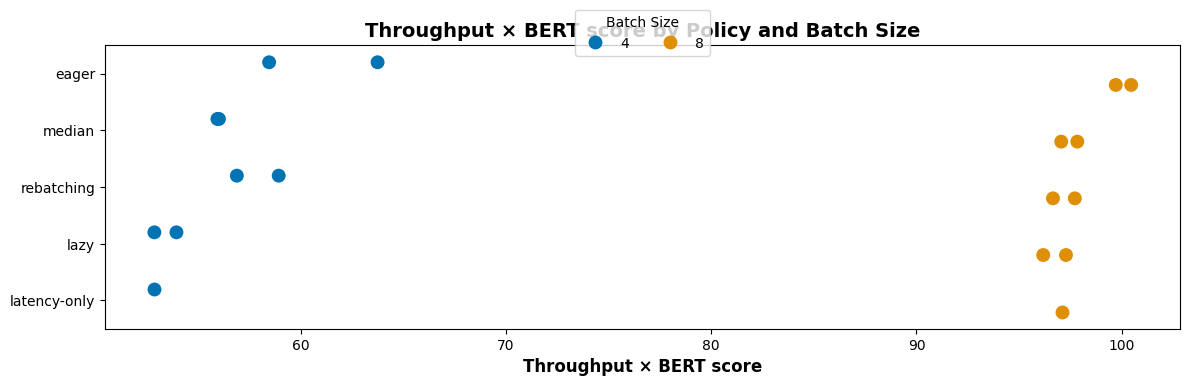

      policy  batch layer conf  throughput  bert_score  throughput_bert_product
       eager      8    30  0.9  136.313034    0.736999               100.462572
       eager      8    25  0.8  137.102110    0.727297                99.713923
      median      8    30  0.9  118.473895    0.825833                97.839609
  rebatching      8    30  0.9  121.429093    0.804730                97.717688
        lazy      8    25  0.8  116.946367    0.831891                97.286610
latency-only      8    30  1.0  116.727802    0.831971                97.114110
      median      8    25  0.8  118.118095    0.821679                97.055198
  rebatching      8    25  0.8  122.449911    0.789330                96.653404
        lazy      8    30  0.9  115.920878    0.829687                96.178009
       eager      4    25  0.8   89.297787    0.713758                63.737014
  rebatching      4    30  0.9   72.863116    0.808623                58.918808
       eager      4    30  0.9   81.4850

In [5]:
def throughput_bert_product_table_and_plot(data_dir):
    """
    Loads *_numeric.csv files and calculates throughput × BERT score for 
    latency-only and rebatching policies at batch sizes 4 and 8.
    Prints a DataFrame showing this product and plots throughput × bert_score vs throughput on one axis.
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    pattern = re.compile(
        r"batch_([0-9]+)_layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy_.*_numeric\.csv$"
    )

    rows = []
    policies_of_interest = ["latency-only", "rebatching", "lazy", "median", "eager"]
    batches_of_interest = [4, 8]

    for csv_path in data_dir.glob("*_numeric.csv"):
        fname = csv_path.name
        m = pattern.search(fname)
        if not m:
            continue
        
        batch = int(m.group(1))
        layer = m.group(2)
        conf = m.group(3)
        policy = m.group(4)

        if policy not in policies_of_interest or batch not in batches_of_interest:
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Failed reading {fname}: {e}")
            continue

        throughput = df["throughput"].mean()
        bert_score = df["bert_score"].mean()
        product = throughput * bert_score

        rows.append({
            "policy": policy,
            "batch": batch,
            "layer": layer,
            "conf": conf,
            "throughput": throughput,
            "bert_score": bert_score,
            "throughput_bert_product": product,
        })

    df = pd.DataFrame(rows)

    # Sort for presentation
    df = df.sort_values(by=["throughput_bert_product"], ascending=False).reset_index(drop=True)

    print("Throughput × BERT score product table:")
    print(df.to_string(index=False))

    plt.figure(figsize=(12, 4))
    sns.stripplot(
        data=df,
        x="throughput_bert_product",
        y="policy",           # Use policy or another categorical var on y for separation
        hue="batch",          # Color by batch size
        dodge=True,
        size=10,
        palette="colorblind",
        jitter=False  # Disable jitter for perfect vertical alignment
    )

    plt.xlabel("Throughput × BERT score", fontsize=12, fontweight='bold')
    plt.ylabel("")  # Optional: hide y-axis label if you want clean look
    plt.title("Throughput × BERT score by Policy and Batch Size", fontsize=14, fontweight='bold')
    plt.legend(
        title="Batch Size",
        loc='upper center',          # Position at the top center inside the axes
        bbox_to_anchor=(0.5, 1.15),  # Shift slightly above the plot area (adjust vertical position)
        ncol=2                       # Arrange legend items in a horizontal row
    )
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    return df

# Example usage:
result_df = throughput_bert_product_table_and_plot(data_dir)
print(result_df.to_string(index=False))

In [3]:
import pandas as pd
import csv
import re
from pathlib import Path

def clean_unquoted_multiline_csv_keep_seq_id(data_dir, numeric_headers, expected_numeric_count=32):
    """
    Improved robust cleaner:
    - Merges all lines until a line starts with a seq_id integer and comma.
    - After merging and parsing, skips all empty fields after seq_id,
      then takes the next N fields as numeric columns.
    - Handles edge cases with leading commas in numeric extraction.
    - Preserves seq_id as first column.
    """

    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    output_headers = ['seq_id'] + numeric_headers
    for csv_path in data_dir.glob("*.csv"):
        print(f"Processing: {csv_path.name}")
        fixed_rows = []
        buffer_lines = []
        with open(csv_path, "r", encoding="utf-8", errors="replace") as infile:
            for line in infile:
                line = line.rstrip('\r\n')
                # Detect new row starts by integer at start
                if re.match(r'^\d+,', line) and buffer_lines:
                    # flush previous buffer as one CSV record
                    buffer_str = '\n'.join(buffer_lines)
                    reader = csv.reader([buffer_str])
                    try:
                        fields = next(reader)
                        seq_id = fields[0]
                        # skip empty fields after seq_id
                        tail_fields = fields[1:]
                        # Find index in tail_fields where numeric part starts
                        numeric_start = 0
                        while numeric_start < len(tail_fields):
                            try:
                                float(tail_fields[numeric_start])
                                break
                            except:
                                numeric_start += 1
                        # Now grab expected count from there
                        numeric_values = []
                        for part in tail_fields[numeric_start:numeric_start+expected_numeric_count]:
                            try:
                                numeric_values.append(float(part))
                            except:
                                numeric_values.append(None)
                        # Only add valid rows (optional: require most values present)
                        if sum(v is not None for v in numeric_values) > expected_numeric_count // 2:
                            fixed_rows.append([seq_id] + numeric_values)
                    except Exception:
                        pass
                    buffer_lines = [line]
                else:
                    buffer_lines.append(line)
            # flush last buffer
            if buffer_lines:
                buffer_str = '\n'.join(buffer_lines)
                reader = csv.reader([buffer_str])
                try:
                    fields = next(reader)
                    seq_id = fields[0]
                    tail_fields = fields[1:]
                    numeric_start = 0
                    while numeric_start < len(tail_fields):
                        try:
                            float(tail_fields[numeric_start])
                            break
                        except:
                            numeric_start += 1
                    numeric_values = []
                    for part in tail_fields[numeric_start:numeric_start+expected_numeric_count]:
                        try:
                            numeric_values.append(float(part))
                        except:
                            numeric_values.append(None)
                    if sum(v is not None for v in numeric_values) > expected_numeric_count // 2:
                        fixed_rows.append([seq_id] + numeric_values)
                except Exception:
                    pass
        # Save cleaned csv
        output_path = csv_path.with_name(csv_path.stem + "_numeric.csv")
        df = pd.DataFrame(fixed_rows, columns=output_headers)
        df.to_csv(output_path, index=False, encoding="utf-8", errors="replace")
        print(f"  Saved numeric-only csv with seq_id: {output_path.name}")


numeric_headers = [
    'time','throughput','rougeL','bert_score','prefill_time','decode_time','tpot',
    'num_ee_tokens','num_no_ee_tokens','avg_conf_score','avg_conf_score_ee','avg_conf_score_non_ee',
    'num_ee_iter','num_no_ee_iter','tokens_per_iter','avg_normal_iter_time','avg_ee_iter_time','avg_deep_iter_time',
    'total_iter_time','avg_normal_iter_num_output_tokens','avg_ee_iter_num_output_tokens','avg_deep_iter_num_output_tokens',
    'ee_penalty_by_tokens','ee_penalty_by_iter','ee_bert_penalty_by_tokens','ee_bert_penalty_by_iter',
    'tbt_avg','tbt_p95','tbt_p99','request_duration','request_duration_avg','request_duration_p95','request_duration_p99'
]

clean_unquoted_multiline_csv_keep_seq_id(data_dir, numeric_headers, expected_numeric_count=len(numeric_headers))

Processing: req_2160_batch_4_layer_30_conf_0.9_median_copy_run_01.csv
  Saved numeric-only csv with seq_id: req_2160_batch_4_layer_30_conf_0.9_median_copy_run_01_numeric.csv
Processing: req_2160_batch_4_layer_30_conf_0.9_rebatching_copy_run_02.csv
  Saved numeric-only csv with seq_id: req_2160_batch_4_layer_30_conf_0.9_rebatching_copy_run_02_numeric.csv
Processing: req_2160_batch_4_layer_30_conf_1.0_latency-only_copy_run_01.csv
  Saved numeric-only csv with seq_id: req_2160_batch_4_layer_30_conf_1.0_latency-only_copy_run_01_numeric.csv
Processing: req_2160_batch_4_layer_30_conf_0.9_lazy_copy_run_01.csv
  Saved numeric-only csv with seq_id: req_2160_batch_4_layer_30_conf_0.9_lazy_copy_run_01_numeric.csv
Processing: req_2160_batch_4_layer_30_conf_0.9_eager_copy_run_01.csv
  Saved numeric-only csv with seq_id: req_2160_batch_4_layer_30_conf_0.9_eager_copy_run_01_numeric.csv
